# 04 - Fake Detection & Business Analytics


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set(style="whitegrid", palette="magma")
np.random.seed(42)


In [ ]:
# Load stage 3 features
input_path = os.path.join("..", "data", "stage3_features.csv")
df = pd.read_csv(input_path)
df["review_date"] = pd.to_datetime(df["review_date"])
print(f"Loaded {len(df)} reviews.")


Loaded 69737 reviews.


##  User Behavior Analysis (Flooding Detection)
We identify users who post multiple reviews in short intervals (e.g., within 60 seconds), a common sign of bot activity.


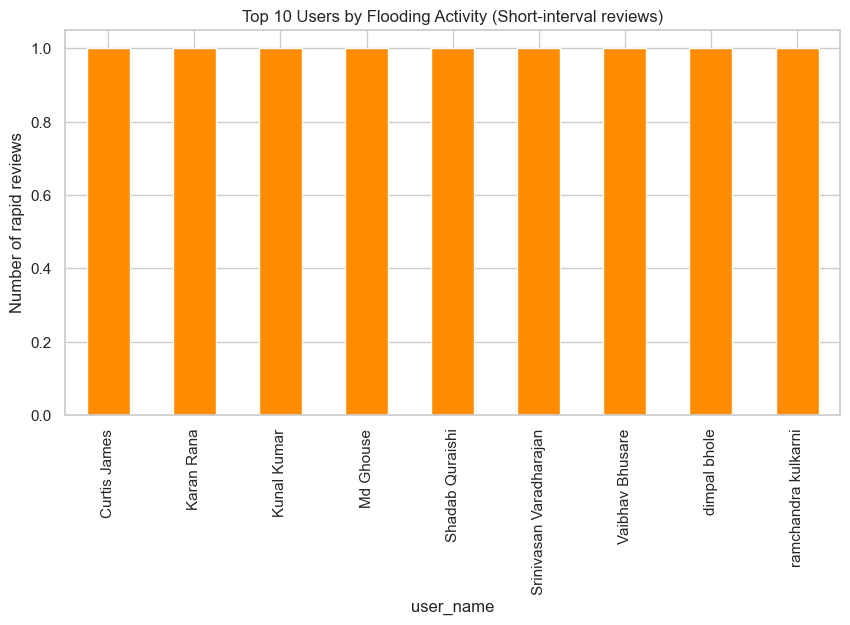

In [ ]:
# Identify "Review Flooding"
df = df.sort_values(by=["user_name", "review_date"])
df["time_diff"] = df.groupby("user_name")["review_date"].diff().dt.total_seconds()

# Count reviews by same user within 60 seconds
df["is_flooding"] = df["time_diff"] < 60
df["flooding_count"] = df.groupby("user_name")["is_flooding"].transform("sum")

# Visualization: Top Flooders
top_flooders = df[df["flooding_count"] > 0].groupby("user_name")["flooding_count"].max().sort_values(ascending=False).head(10)
if not top_flooders.empty:
    plt.figure(figsize=(10, 5))
    top_flooders.plot(kind="bar", color="darkorange")
    plt.title("Top 10 Users by Flooding Activity (Short-interval reviews)")
    plt.ylabel("Number of rapid reviews")
    plt.show()
else:
    print("No rapid flooding detected in this dataset version.")


##  Business Analytics: Customer Segmentation (K-Means)
We group reviews into 4 clusters to understand different customer behaviors (e.g., critics, loyalists, anomalies).


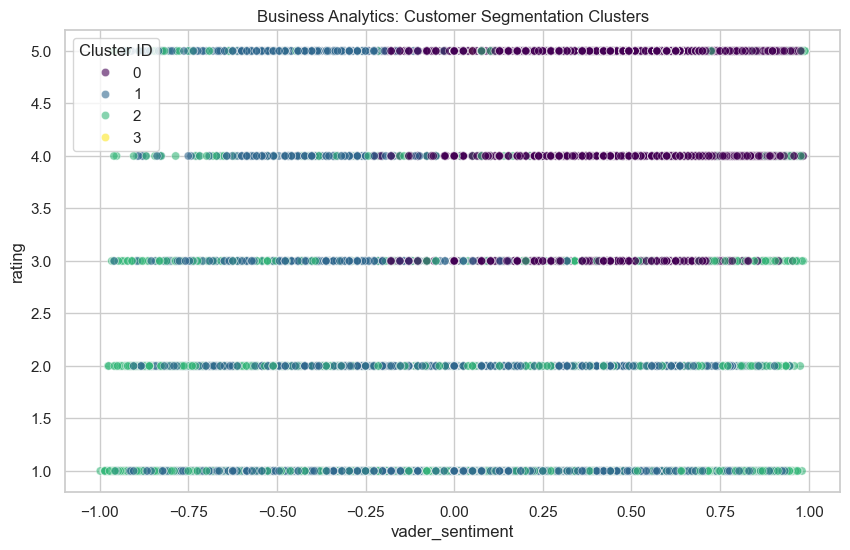

In [ ]:
features = ['rating', 'review_len', 'word_count', 'vader_sentiment', 'sentiment_inconsistency', 'flooding_count']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features].fillna(0))

# K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["customer_segment"] = kmeans.fit_predict(X_scaled)

# Visualization: Segments by Rating and Sentiment
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="vader_sentiment", y="rating", hue="customer_segment", palette="viridis", alpha=0.6)
plt.title("Business Analytics: Customer Segmentation Clusters")
plt.legend(title="Cluster ID")
plt.show()


## Hybrid Detection: Unsupervised Consensus
Using Isolation Forest and One-Class SVM to flag outliers based on all behavioral features.


In [ ]:
# Model 1: Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
df["iso_pred"] = iso.fit_predict(X_scaled)

# Model 2: One-Class SVM
oc_svm = OneClassSVM(nu=0.05, kernel="rbf")
df["svm_pred"] = oc_svm.fit_predict(X_scaled)

# Consensus: A review is "Label_Fake" if BOTH models agree it's an outlier
df["consensus_label"] = np.where((df["iso_pred"] == -1) & (df["svm_pred"] == -1), 1, 0)
print(f"High-Confidence Fake Reviews found: {df['consensus_label'].sum()}")


High-Confidence Fake Reviews found: 1891


## Supervised Random Forest Classifier (80/20 Split)
Training a standard classifier to learn from our high-confidence consensus labels.


In [ ]:
# Split the data
X = df[features].fillna(0)
y = df["consensus_label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluation
y_pred = rf_model.predict(X_test)
print(f"Final Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Final Model Accuracy: 99.69%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     13589
           1       0.96      0.92      0.94       359

    accuracy                           1.00     13948
   macro avg       0.98      0.96      0.97     13948
weighted avg       1.00      1.00      1.00     13948



## Model Interpretation: Feature Importance
Which behaviors are the strongest indicators of fake reviews in this dataset?


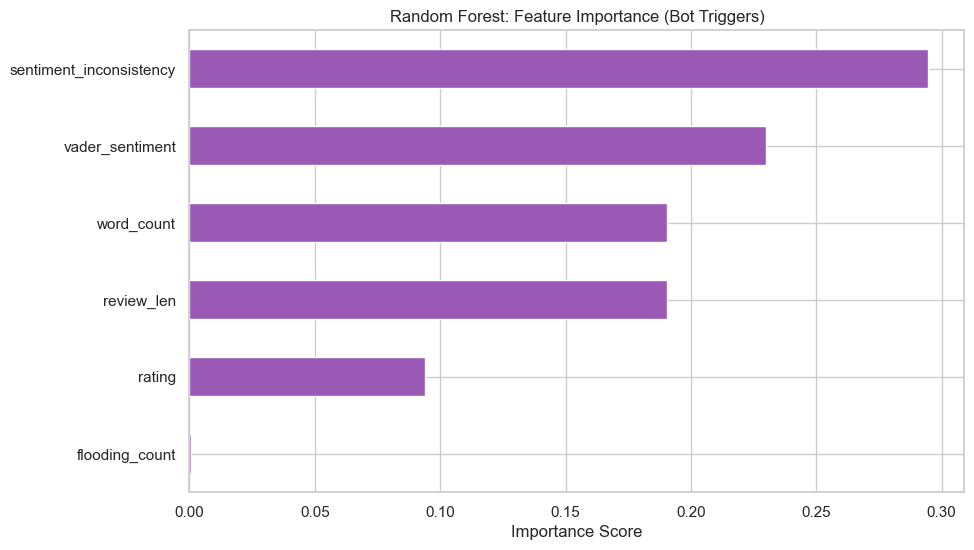

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#9b59b6')
plt.title("Random Forest: Feature Importance (Bot Triggers)")
plt.xlabel("Importance Score")
plt.show()


## Results Export


In [ ]:
output_path = os.path.join("..", "data", "final_results.csv")
df["final_prediction"] = rf_model.predict(X)
df.to_csv(output_path, index=False)
print(f"Final results saved to {output_path}")


Final results saved to ..\data\final_business_analytics_results.csv
